# 🔌 Projeto: Engenharia de Dados em Big Data
## Onde Construir um Datacenter no Brasil?
### Etapa 2 — Análise Exploratória e Limpeza de Dados (Silver → Gold)

**Disciplina:** Fundamentos de Dados e Analytics — Engenharia de Dados em Big Data  
**Profs.:** Fabio Rossi Versolatto · Gustavo Moreira Calixto

> **Fonte de dados:** 100% MongoDB Atlas (camada Bronze já ingerida na Etapa 1).  
> Esta etapa transforma Bronze → Silver → Gold e realiza a EDA completa.

---

## 0.1 — Instalação de dependências

In [21]:
!pip install -q pymongo dnspython plotly xgboost openpyxl

## 0.2 — Imports

In [22]:
import os, re
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path
from scipy.spatial import cKDTree
from pymongo import MongoClient, ASCENDING
from pymongo.errors import BulkWriteError
import warnings
warnings.filterwarnings('ignore')
print('✅ Imports prontos.')

✅ Imports prontos.


## 0.3 — Conexão MongoDB Atlas

> **Pré-requisito:** secret `MONGO_URI` cadastrado em *Colab → 🔑 Secrets*  
> (mesmo procedimento da Etapa 1)

In [23]:
from google.colab import userdata

MONGO_URI = userdata.get('MONGO_URI')
assert MONGO_URI, '❌ Cadastre o secret MONGO_URI em Configurações → Secrets'

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=15000)
client.admin.command('ping')
db = client['aneel_datacenters_v2']
print('✅ Conectado ao MongoDB Atlas. Banco:', db.name)
print('📋 Coleções disponíveis:', sorted(db.list_collection_names()))

✅ Conectado ao MongoDB Atlas. Banco: aneel_datacenters_v2
📋 Coleções disponíveis: ['bronze_anatel_compartilhamento', 'bronze_anatel_credenciadas', 'bronze_anatel_interconexao', 'bronze_anatel_mvno', 'bronze_anatel_ran_sharing', 'bronze_datacenters', 'bronze_inmet_estacoes', 'bronze_siga', 'gold_empreendimentos_features', 'gold_predicoes_potencia', 'gold_ranking_atratividade_dc', 'silver_anatel_uf', 'silver_datacenters', 'silver_inmet', 'silver_siga']


## 0.4 — Funções utilitárias

In [24]:
def colecao_tem_dados(nome, minimo=1):
    """Retorna True se a coleção tem >= `minimo` documentos."""
    try:
        return db[nome].estimated_document_count() >= minimo
    except Exception:
        return False

def verificar_bronze():
    """Verifica que todas as coleções Bronze estão populadas antes de prosseguir."""
    bronze_esperadas = [
        'bronze_siga',
        'bronze_inmet_estacoes',
        'bronze_anatel_compartilhamento',
        'bronze_anatel_credenciadas',
        'bronze_anatel_interconexao',
        'bronze_anatel_mvno',
        'bronze_anatel_ran_sharing',
        'bronze_datacenters',
    ]
    ok = True
    for nome in bronze_esperadas:
        n = db[nome].estimated_document_count()
        status = '✅' if n else '❌'
        print(f'{status} {nome:40s} {n:>10,} docs')
        if not n:
            ok = False
    if not ok:
        raise RuntimeError(
            '❌ Uma ou mais coleções Bronze estão vazias.\n'
            'Execute a Etapa 1 (ingestão) antes de prosseguir.'
        )
    print('\n✅ Todas as coleções Bronze verificadas com sucesso.')

verificar_bronze()

✅ bronze_siga                                  25,407 docs
✅ bronze_inmet_estacoes                           499 docs
✅ bronze_anatel_compartilhamento                9,630 docs
✅ bronze_anatel_credenciadas                      196 docs
✅ bronze_anatel_interconexao                   12,374 docs
✅ bronze_anatel_mvno                              341 docs
✅ bronze_anatel_ran_sharing                        17 docs
✅ bronze_datacenters                           18,112 docs

✅ Todas as coleções Bronze verificadas com sucesso.


---
# 🟨 ETAPA 2 — Análise Exploratória e Limpeza (Silver + Gold)

> A camada **Silver** limpa, tipa e valida os dados Bronze.  
> A camada **Gold** agrega features prontas para ML.

## 2.0 — Atalho: recarregar Silver/Gold do Mongo se já existirem

## Dicionário de Dados da Camada Silver

Este dicionário descreve as colunas presentes nos datasets da camada Silver, com descrições geradas por IA para facilitar a compreensão dos dados após o processo de limpeza e transformação.

In [25]:
silver_columns = set()
silver_columns.update(df_siga.columns)
silver_columns.update(silver_inmet.columns)
silver_columns.update(silver_anatel.columns)
silver_columns.update(silver_dc.columns)

# Exclude temporary or internal columns that are not part of the final silver layer schema for analysis
excluded_columns = [
    '_id', '_ingest_ts', '_source', '_source_url',
    'ESTACAO_CODIGO', 'index', 'UF'
]
silver_columns = sorted([col for col in silver_columns if col not in excluded_columns])

data_dictionary = {
    'CodCEG': 'Código de Empreendimento de Geração (ANEEL), identificador único do empreendimento.',
    'DatGeracaoConjuntoDados': 'Data de geração do conjunto de dados da ANEEL.',
    'NomEmpreendimento': 'Nome do empreendimento de geração de energia.',
    'IdeNucleoCEG': 'Identificador do Núcleo do Código de Empreendimento de Geração.',
    'SigTipoGeracao': 'Sigla do tipo de geração de energia (ex: UFV, UTE, EOL).',
    'SigUFPrincipal': 'Sigla da Unidade Federativa (estado) onde o empreendimento está localizado.',
    'MdaPotenciaOutorgadaKw': 'Potência outorgada (autorizada) do empreendimento em Kilowatts (kW).',
    'MdaPotenciaFiscalizadaKw': 'Potência fiscalizada do empreendimento em Kilowatts (kW).',
    'DscOrigemCombustivel': 'Descrição da origem do combustível utilizado na geração (ex: Hídrica, Fóssil, Solar).',
    'DscFaseUsina': 'Fase atual do empreendimento (ex: Operação, Construção, Construção não iniciada).',
    'DscTipoOutorga': 'Tipo de outorga concedida ao empreendimento (ex: Autorização, Concessão).',
    'DatEntradaOperacao': 'Data de entrada em operação comercial do empreendimento.',
    'DatInicioVigencia': 'Data de início da vigência da outorga.',
    'DatFimVigencia': 'Data de fim da vigência da outorga.',
    'NomeCombustivel': 'Nome detalhado do combustível utilizado (se aplicável).',
    'DscSubBacia': 'Descrição da sub-bacia hidrográfica onde o empreendimento hídrico está localizado.',
    'MdaGarantiaFisicaKw': 'Garantia física do empreendimento em Kilowatts (kW).',
    'IdcGeracaoQualificada': 'Indicador de geração qualificada (se o empreendimento se enquadra em critérios específicos).',
    'DatPublicacao': 'Data de publicação dos dados do empreendimento.',
    'NumCoordNEmpreendimento': 'Coordenada Norte (latitude) original do empreendimento na base Bronze.',
    'NumCoordEEmpreendimento': 'Coordenada Leste (longitude) original do empreendimento na base Bronze.',
    'lat': 'Latitude padronizada WGS-84 do empreendimento.',
    'lon': 'Longitude padronizada WGS-84 do empreendimento.',
    'eh_renovavel': 'Flag booleano indicando se a fonte de energia é renovável (True/False).',
    'REGIAO': 'Região do Brasil onde a estação INMET está localizada.',
    'ESTACAO': 'Nome da estação meteorológica do INMET.',
    'CODIGO (WMO)': 'Código da estação meteorológica conforme Organização Meteorológica Mundial (WMO).',
    'LATITUDE': 'Latitude da estação meteorológica ou do datacenter.',
    'LONGITUDE': 'Longitude da estação meteorológica ou do datacenter.',
    'ALTITUDE': 'Altitude da estação meteorológica em metros.',
    'DATA_INICIO': 'Data de início do período de observação da estação INMET.',
    'DATA_FIM': 'Data de fim do período de observação da estação INMET.',
    'temp_media': 'Temperatura média do ar (°C) agregada por estação.',
    'temp_std': 'Desvio padrão da temperatura do ar (°C) agregada por estação.',
    'temp_max': 'Temperatura máxima do ar (°C) agregada por estação.',
    'temp_min': 'Temperatura mínima do ar (°C) agregada por estação.',
    'umid_media': 'Umidade relativa média do ar (%) agregada por estação.',
    'prec_total': 'Precipitação total (mm) agregada por estação.',
    'prec_max_h': 'Precipitação máxima horária (mm) agregada por estação.',
    'radiacao_med': 'Radiação global média (kJ/m²) agregada por estação.',
    'vento_med': 'Velocidade média do vento (m/s) agregada por estação.',
    'rajada_max': 'Velocidade máxima da rajada de vento (m/s) agregada por estação.',
    'n_obs': 'Número de observações válidas para as variáveis climáticas da estação.',
    'anatel_compartilhamento': 'Contagem de menções em documentos de compartilhamento da ANATEL para a UF.',
    'anatel_interconexao': 'Contagem de menções em documentos de interconexão da ANATEL para a UF.',
    'anatel_mvno': 'Contagem de menções em documentos de MVNO (Mobile Virtual Network Operator) da ANATEL para a UF.',
    'anatel_ran_sharing': 'Contagem de menções em documentos de RAN Sharing (Radio Access Network) da ANATEL para a UF.',
    'anatel_credenciadas': 'Contagem de menções em documentos de empresas credenciadas da ANATEL para a UF.',
    'anatel_total': 'Soma total das menções em documentos da ANATEL por UF, um proxy para cobertura de telecomunicações.',
    'name': 'Nome do datacenter.',
    'company': 'Empresa operadora do datacenter.',
    'city': 'Cidade onde o datacenter está localizado.',
    'state': 'Estado onde o datacenter está localizado.',
    'country': 'País onde o datacenter está localizado.',
    'address': 'Endereço completo do datacenter.'
}

print("## Dicionário de Dados da Camada Silver\n")
for col, desc in data_dictionary.items():
    print(f"- **{col}**: {desc}")

## Dicionário de Dados da Camada Silver

- **CodCEG**: Código de Empreendimento de Geração (ANEEL), identificador único do empreendimento.
- **DatGeracaoConjuntoDados**: Data de geração do conjunto de dados da ANEEL.
- **NomEmpreendimento**: Nome do empreendimento de geração de energia.
- **IdeNucleoCEG**: Identificador do Núcleo do Código de Empreendimento de Geração.
- **SigTipoGeracao**: Sigla do tipo de geração de energia (ex: UFV, UTE, EOL).
- **SigUFPrincipal**: Sigla da Unidade Federativa (estado) onde o empreendimento está localizado.
- **MdaPotenciaOutorgadaKw**: Potência outorgada (autorizada) do empreendimento em Kilowatts (kW).
- **MdaPotenciaFiscalizadaKw**: Potência fiscalizada do empreendimento em Kilowatts (kW).
- **DscOrigemCombustivel**: Descrição da origem do combustível utilizado na geração (ex: Hídrica, Fóssil, Solar).
- **DscFaseUsina**: Fase atual do empreendimento (ex: Operação, Construção, Construção não iniciada).
- **DscTipoOutorga**: Tipo de outorga concedid

# Verificação de carregamento
Este código verifica se as camadas Silver e Gold já foram computadas e persistidas no MongoDB. Se sim, ele as carrega diretamente do banco de dados para acelerar o processo, evitando recomputações demoradas. Caso contrário, ele sinaliza que as camadas serão processadas nas próximas células.

In [26]:
SKIP_RECOMPUTE = all(
    colecao_tem_dados(c) for c in
    ['silver_siga', 'silver_inmet', 'silver_anatel_uf',
     'silver_datacenters', 'gold_empreendimentos_features']
)

if SKIP_RECOMPUTE:
    print('⚡ Carregando Silver/Gold do MongoDB (sem recomputar)...')
    df_siga       = pd.DataFrame(list(db['silver_siga'].find({}, {'_id': 0})))
    silver_inmet  = pd.DataFrame(list(db['silver_inmet'].find({}, {'_id': 0})))
    silver_anatel = pd.DataFrame(list(db['silver_anatel_uf'].find({}, {'_id': 0})))
    silver_dc     = pd.DataFrame(list(db['silver_datacenters'].find({}, {'_id': 0})))
    emp           = pd.DataFrame(list(db['gold_empreendimentos_features'].find({}, {'_id': 0})))
    print(f'   silver_siga:                   {df_siga.shape}')
    print(f'   silver_inmet:                  {silver_inmet.shape}')
    print(f'   silver_anatel_uf:              {silver_anatel.shape}')
    print(f'   silver_datacenters:            {silver_dc.shape}')
    print(f'   gold_empreendimentos_features: {emp.shape}')
else:
    print('🔁 Silver/Gold ausentes — será recomputado nas células seguintes.')

⚡ Carregando Silver/Gold do MongoDB (sem recomputar)...
   silver_siga:                   (25407, 26)
   silver_inmet:                  (499, 21)
   silver_anatel_uf:              (27, 7)
   silver_datacenters:            (18112, 10)
   gold_empreendimentos_features: (25053, 28)


## 2.1 — Silver: limpeza e tipagem do SIGA-ANEEL

Origem: `bronze_siga` (MongoDB) → `silver_siga`

Operações efetuadas para melhoria e limpeza:
- Campos numéricos em formato BR (`1.234,56`) → float
- Datas → datetime
- Coordenadas (graus/minutos/segundos ou decimal) → float WGS-84
- Sanitização de coordenadas fora do Brasil, pois a analise será focada em território nacional.
- Flag `eh_renovavel`

In [40]:
if not SKIP_RECOMPUTE:
    # Função para converter strings numéricas no formato brasileiro (ex: '1.234,56') para float
    def to_float_br(s):
        """Converte string numérica BR ('1.234,56') -> float."""
        if pd.isna(s) or s in ('', '-', 'N/A', 'nan'):
            return np.nan
        s = str(s).replace('.', '').replace(',', '.')
        try:
            return float(s)
        except ValueError:
            return np.nan

    # Função para analisar e converter strings de coordenadas (decimal ou GMS) para float no formato WGS-84
    def parse_coord(s):
        """Converte coordenada texto (decimal ou GMS) -> float."""
        if pd.isna(s) or str(s).strip() == '':
            return np.nan
        s = str(s).strip()
        try:
            return float(s.replace(',', '.'))
        except Exception:
            pass
        # Expressão regular para capturar graus, minutos, segundos e hemisfério
        m = re.match(r"(\d+)[°\s]+(\d+)['′\s]+([\d\.,]+)?\"?\s*([NSEWO])", s)
        if m:
            d, mi, se, hem = m.groups()
            se = float((se or '0').replace(',', '.'))
            val = float(d) + float(mi) / 60 + se / 3600
            if hem in ('S', 'W', 'O'): # Ajusta o sinal para hemisférios Sul/Oeste
                val = -val
            return val
        return np.nan

    # ── Carrega Bronze SIGA do MongoDB ───────────────────────────────────────
    # Carrega os dados da coleção 'bronze_siga' do MongoDB para um DataFrame Pandas.
    # Exclui campos de metadados como '_id', '_ingest_ts', '_source', '_source_url'.
    df_siga = pd.DataFrame(list(db['bronze_siga'].find(
        {}, {'_id': 0, '_ingest_ts': 0, '_source': 0, '_source_url': 0}
    )))
    print('Bronze SIGA shape:', df_siga.shape)

    # Numéricos: Aplica a função `to_float_br` para converter colunas numéricas com formato BR.
    for c in ['MdaPotenciaOutorgadaKw', 'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw']:
        if c in df_siga.columns:
            df_siga[c] = df_siga[c].apply(to_float_br)

    # Datas: Converte colunas de data para o tipo datetime do Pandas.
    for c in ['DatGeracaoConjuntoDados', 'DatEntradaOperacao',
              'DatInicioVigencia', 'DatFimVigencia']:
        if c in df_siga.columns:
            df_siga[c] = pd.to_datetime(df_siga[c], errors='coerce') # 'coerce' transforma erros em NaT

    # Coordenadas: Aplica a função `parse_coord` para extrair latitude e longitude.
    # Usa `.get()` com um Series de NaNs para evitar erros se a coluna não existir.
    df_siga['lat'] = df_siga.get(
        'NumCoordNEmpreendimento', pd.Series([np.nan] * len(df_siga))
    ).apply(parse_coord)
    df_siga['lon'] = df_siga.get(
        'NumCoordEEmpreendimento', pd.Series([np.nan] * len(df_siga))
    ).apply(parse_coord)

    # Sanitiza coordenadas que estão fora da região aproximada do Brasil.
    df_siga.loc[~df_siga['lat'].between(-35, 6),   'lat'] = np.nan
    df_siga.loc[~df_siga['lon'].between(-75, -30), 'lon'] = np.nan

    # Flag renovável: Cria uma nova coluna booleana `eh_renovavel` baseada na origem do combustível.
    RENOVAVEL = ['HÍDRICA', 'EÓLICA', 'RADIAÇÃO SOLAR', 'BIOMASSA', 'MARÉS', 'HIDRAULICA']
    df_siga['eh_renovavel'] = df_siga.get('DscOrigemCombustivel', pd.Series('')).isin(RENOVAVEL)

    print(f'✅ Silver SIGA. Com lat/lon: '
          f'{df_siga[["lat","lon"]].notna().all(axis=1).sum():,} empreendimentos')

    # Persiste Silver SIGA: Salva o DataFrame limpo na coleção 'silver_siga' no MongoDB.
    col_silver_siga = db['silver_siga']
    col_silver_siga.drop() # Apaga a coleção existente para recriação
    silver_docs = df_siga.copy()
    # Converte colunas datetime para formato ISO 8601 string para compatibilidade com MongoDB
    for c in ['DatGeracaoConjuntoDados', 'DatEntradaOperacao',
              'DatInicioVigencia', 'DatFimVigencia']:
        if c in silver_docs.columns:
            silver_docs[c] = silver_docs[c].apply(
                lambda x: x.isoformat() if pd.notna(x) else None
            )
    col_silver_siga.insert_many(silver_docs.to_dict(orient='records')) # Insere os documentos
    # Cria índices para otimizar queries futuras
    col_silver_siga.create_index([('SigUFPrincipal', 1), ('DscFaseUsina', 1)])
    print(f'✅ silver_siga persistida: {col_silver_siga.estimated_document_count():,} docs')

# Exibe as primeiras linhas do DataFrame processado com colunas selecionadas para verificação.
df_siga[['NomEmpreendimento', 'SigUFPrincipal', 'SigTipoGeracao', 'DscFaseUsina',
         'MdaPotenciaOutorgadaKw', 'MdaPotenciaFiscalizadaKw',
         'lat', 'lon', 'eh_renovavel']].head()

,NomEmpreendimento,SigUFPrincipal,SigTipoGeracao,DscFaseUsina,MdaPotenciaOutorgadaKw,MdaPotenciaFiscalizadaKw,lat,lon,eh_renovavel
0,G,MG,PCH,Operação,1440.0,1440.0,-20.137545,-43.891926,False
1,Alto Guarajus,RO,UTE,Operação,232.0,232.0,-12.999998,-60.944804,False
2,Walter Rossi (Antiga Antas II),MG,UHE,Operação,16500.0,16500.0,-21.763333,-46.605000,False
3,Novo Aripuanã,AM,UTE,Operação,7670.0,7670.0,-5.120666,-60.380436,False
4,Bahia Pulp (Antiga Bacell),BA,UTE,Operação,108600.0,108600.0,-12.643082,-38.337171,False


## 2.2 — Silver: agregação climática INMET por estação

Origem: `bronze_inmet_estacoes` (MongoDB) → `silver_inmet`

Variáveis climáticas agregadas por estação (média, std, min, max do trimestre):

| Variável                 | Por que importa para um DC           |
|--------------------------|--------------------------------------|
| Temperatura do ar (°C)   | Custo de refrigeração — PUE          |
| Umidade relativa (%)     | Corrosão e condensação               |
| Precipitação (mm)        | Risco de enchente                    |
| Radiação global (kJ/m²)  | Potencial fotovoltaico               |
| Vento — rajada (m/s)     | Risco estrutural                     |

In [41]:
if not SKIP_RECOMPUTE:
    # Função utilitária para converter valores numéricos, tratando NaNs e formatos inválidos.
    def converter_num(x):
        if pd.isna(x) or str(x).strip() in ('', '-9999', 'null'):
            return np.nan
        try:
            return float(str(x).replace(',', '.'))
        except Exception:
            return np.nan

    # Mapeamento de colunas originais (bronze) para nomes mais amigáveis (silver).
    COLS_NUM = {
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)':              'prec_mm',
        'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_c',
        'UMIDADE RELATIVA DO AR, HORARIA (%)':           'umid_rel',
        'RADIACAO GLOBAL (Kj/m²)':                       'radiacao',
        'VENTO, RAJADA MAXIMA (m/s)':                    'vento_rajada',
        'VENTO, VELOCIDADE HORARIA (m/s)':               'vento_vel',
    }

    # ── Carrega observações horárias do MongoDB ───────────────────────────────
    print('⏳ Carregando bronze_inmet_obs do MongoDB...')
    # Carrega todos os documentos da coleção 'bronze_inmet_obs', excluindo o '_id'.
    df_obs_full = pd.DataFrame(list(db['bronze_inmet_obs'].find({}, {'_id': 0})))
    print('Shape obs INMET:', df_obs_full.shape)

    # Renomeia as colunas do DataFrame com base no mapeamento COLS_NUM.
    ren = {k: v for k, v in COLS_NUM.items() if k in df_obs_full.columns}
    df_obs = df_obs_full.rename(columns=ren).copy()
    # Aplica a função `converter_num` para limpar e tipar as colunas numéricas.
    for v in ren.values():
        df_obs[v] = df_obs[v].apply(converter_num)

    print('Colunas climáticas disponíveis:', list(ren.values()))

    # ── Metadados das estações ────────────────────────────────────────────────
    # Carrega os metadados das estações INMET do MongoDB.
    estacoes_df = pd.DataFrame(list(db['bronze_inmet_estacoes'].find(
        {}, {'_id': 0, '_ingest_ts': 0, '_source': 0}
    )))

    # Agrega as observações horárias por estação (ESTACAO_CODIGO).
    # Calcula diversas estatísticas (média, std, min, max, soma, contagem) para as variáveis climáticas.
    agg = (df_obs.groupby('ESTACAO_CODIGO')
           .agg(
               temp_media   =('temp_c',       'mean'),
               temp_std     =('temp_c',       'std'),
               temp_max     =('temp_c',       'max'),
               temp_min     =('temp_c',       'min'),
               umid_media   =('umid_rel',     'mean'),
               prec_total   =('prec_mm',      'sum'),
               prec_max_h   =('prec_mm',      'max'),
               radiacao_med =('radiacao',     'mean'),
               vento_med    =('vento_vel',    'mean'),
               rajada_max   =('vento_rajada', 'max'),
               n_obs        =('temp_c',       'count'),
           )
           .reset_index())

    # Junta os metadados das estações com os dados climáticos agregados.
    silver_inmet = estacoes_df.merge(
        agg, left_on='CODIGO (WMO)', right_on='ESTACAO_CODIGO', how='left'
    )
    # Remove estações que não possuem informações de latitude ou longitude válidas.
    silver_inmet = silver_inmet.dropna(subset=['LATITUDE', 'LONGITUDE'])
    print(f'✅ Silver INMET: {len(silver_inmet)} estações com clima agregado')

    # Persiste Silver INMET: Salva o DataFrame processado na coleção 'silver_inmet' no MongoDB.
    col_silver_inmet = db['silver_inmet']
    col_silver_inmet.drop() # Apaga a coleção existente para recriação.
    col_silver_inmet.insert_many(silver_inmet.to_dict(orient='records')) # Insere os documentos.
    col_silver_inmet.create_index([('UF', 1)]) # Cria um índice na coluna 'UF' para otimização.
    print(f'✅ silver_inmet persistida: {col_silver_inmet.estimated_document_count()} docs')

# Exibe as primeiras linhas do DataFrame processado com colunas selecionadas para verificação.
silver_inmet[['REGIAO', 'UF', 'ESTACAO', 'CODIGO (WMO)', 'LATITUDE', 'LONGITUDE',
              'temp_media', 'umid_media', 'prec_total', 'radiacao_med', 'vento_med']].head()

,REGIAO,UF,ESTACAO,CODIGO (WMO),LATITUDE,LONGITUDE,temp_media,umid_media,prec_total,radiacao_med,vento_med
0,CO,DF,BRASILIA,A001,-15.789444,-47.925833,21.844836,79.464567,522.4,1457.314382,2.197082
1,CO,DF,BRAZLANDIA,A042,-15.652500,-48.201389,21.535294,77.769924,698.8,1381.018038,2.081434
2,CO,DF,AGUAS EMENDADAS,A045,-15.596389,-47.625833,21.741566,80.641798,908.2,1476.696429,1.657692
3,CO,DF,GAMA (PONTE ALTA),A046,-15.935278,-48.137500,22.407550,74.241779,567.6,1284.220669,2.056369
4,CO,DF,PARANOA (COOPA-DF),A047,-16.012222,-47.557500,22.049629,84.244671,731.0,1442.849049,1.803146


## 2.3 — Silver: agregação ANATEL por UF

**Lista de UFs:** Define uma lista com todas as UFs brasileiras para padronização.

**Função contar_uf:** Uma função auxiliar que recebe um DataFrame e colunas de texto, e conta as ocorrências de cada UF dentro desse texto. Isso ajuda a identificar a relevância de cada estado nos documentos da ANATEL.

**Processamento de Coleções ANATEL:** O código itera sobre as cinco coleções bronze_anatel_* (compartilhamento, interconexão, mvno, ran_sharing, credenciadas). Para cada coleção, ele carrega os dados, identifica colunas de texto relevantes e usa a função contar_uf para obter a contagem de menções por UF.

**Agregação Final (silver_anatel):** Os resultados de todas as coleções ANATEL são combinados em um único DataFrame chamado silver_anatel. Uma coluna anatel_total é criada, somando todas as menções de cada UF, e o DataFrame é ordenado por essa soma.

**Persistência no MongoDB:** O DataFrame silver_anatel é salvo em uma nova coleção no MongoDB, silver_anatel_uf, substituindo qualquer versão anterior. Um índice é criado na coluna 'UF' para otimizar futuras consultas.



In [42]:
if not SKIP_RECOMPUTE:
    # Lista de todas as Unidades Federativas (UFs) do Brasil.
    UF_LIST = [
        'AC','AL','AM','AP','BA','CE','DF','ES','GO','MA','MG','MS','MT',
        'PA','PB','PE','PI','PR','RJ','RN','RO','RR','RS','SC','SE','SP','TO'
    ]

    def contar_uf(df, *cols_texto):
        """Conta menções a cada UF nas colunas de texto do DataFrame."""
        # Concatena o texto de todas as colunas especificadas em uma única Series.
        text = pd.Series('', index=df.index)
        for c in cols_texto:
            if c in df.columns:
                text = text.str.cat(df[c].fillna(''), sep=' ')
        # Para cada UF na UF_LIST, conta quantas vezes ela aparece no texto concatenado.
        return pd.Series({
            uf: text.str.contains(rf'\b{uf}\b', case=False, regex=True, na=False).sum()
            for uf in UF_LIST
        })

    # Lista dos nomes das coleções ANATEL no Bronze.
    COLECOES_ANATEL = [
        'compartilhamento', 'interconexao', 'mvno', 'ran_sharing', 'credenciadas'
    ]

    linhas_uf = []
    # Itera sobre cada tipo de documento da ANATEL.
    for nome in COLECOES_ANATEL:
        col_name = f'bronze_anatel_{nome}'
        # Carrega os dados da coleção atual do MongoDB.
        df_a = pd.DataFrame(list(
            db[col_name].find({}, {'_id': 0, '_ingest_ts': 0, '_source': 0})
        ))
        if df_a.empty:
            print(f'⚠️  {col_name} vazia no MongoDB — pulando.')
            continue
        print(f'   • {nome:20s} → {df_a.shape}')
        # Identifica colunas que provavelmente contêm texto relevante para contagem de UF.
        cols_texto = [
            c for c in df_a.columns
            if any(k in c.upper() for k in
                   ('OBSERVACAO', 'PRESTADORA', 'DETENTORA', 'SOLICITANTE',
                    'CREDENCIADA', 'OBS'))
        ]
        # Aplica a função `contar_uf` e armazena o resultado.
        linhas_uf.append(contar_uf(df_a, *cols_texto).rename(f'anatel_{nome}'))

    # Concatena todos os resultados de contagem por UF em um único DataFrame.
    silver_anatel = (
        pd.concat(linhas_uf, axis=1)
        .reset_index()
        .rename(columns={'index': 'UF'})
    )
    # Calcula a soma total de menções ANATEL por UF.
    silver_anatel['anatel_total'] = silver_anatel.iloc[:, 1:].sum(axis=1)
    # Ordena o DataFrame pela coluna 'anatel_total' em ordem decrescente.
    silver_anatel = silver_anatel.sort_values('anatel_total', ascending=False)

    # Persiste Silver ANATEL: Salva o DataFrame processado na coleção 'silver_anatel_uf' no MongoDB.
    col_silver_anatel = db['silver_anatel_uf']
    col_silver_anatel.drop() # Apaga a coleção existente para recriação.
    col_silver_anatel.insert_many(silver_anatel.to_dict(orient='records')) # Insere os documentos.
    print(f'✅ silver_anatel_uf persistida: {col_silver_anatel.estimated_document_count()} UFs')

# Exibe as primeiras 5 linhas do DataFrame processado.
print('✅ Silver ANATEL por UF:')
display(silver_anatel.head(5))

✅ Silver ANATEL por UF:


,UF,anatel_compartilhamento,anatel_interconexao,anatel_mvno,anatel_ran_sharing,anatel_credenciadas,anatel_total
0,GO,59,0,0,0,0,59
1,RS,12,0,2,0,0,14
2,MG,13,0,0,0,0,13
3,SE,2,11,0,0,0,13
4,MS,6,6,0,0,0,12


## 2.4 — Silver: datacenters no Brasil (geocodificação)

Origem: `bronze_datacenters` (MongoDB) → `silver_datacenters`

Junta coordenadas aproximadas das principais cidades brasileiras, e mantém os dados de todas os datacenters, nacionais ou globais.

In [43]:
CIDADES_COORD = {
    'São Paulo':             (-23.5505, -46.6333),
    'Rio de Janeiro':        (-22.9068, -43.1729),
    'Belo Horizonte':        (-19.9167, -43.9345),
    'Brasília':              (-15.7939, -47.8828),
    'Curitiba':              (-25.4284, -49.2733),
    'Porto Alegre':          (-30.0346, -51.2177),
    'Fortaleza':             ( -3.7172, -38.5433),
    'Salvador':              (-12.9714, -38.5014),
    'Recife':                ( -8.0476, -34.8770),
    'Campinas':              (-22.9099, -47.0626),
    'Florianópolis':         (-27.5954, -48.5480),
    'Goiânia':               (-16.6869, -49.2648),
    'Manaus':                ( -3.1190, -60.0217),
    'Belém':                 ( -1.4558, -48.4902),
    'Natal':                 ( -5.7945, -35.2110),
    'João Pessoa':           ( -7.1153, -34.8610),
    'São José dos Campos':   (-23.2237, -45.9009),
    'São José do Rio Preto': (-20.8113, -49.3758),
    'Barueri':               (-23.5111, -46.8761),
    'Osasco':                (-23.5320, -46.7919),
    'Santana de Parnaíba':   (-23.4438, -46.9176),
    'Jundiaí':               (-23.1858, -46.8979),
    'Guarulhos':             (-23.4538, -46.5333),
    'Hortolândia':           (-22.8584, -47.2200),
    'Vitória':               (-20.3155, -40.3128),
    'Caxias do Sul':         (-29.1678, -51.1794),
    'Eusébio':               ( -3.8900, -38.4506),
    'Anápolis':              (-16.3267, -48.9528),
    'Paulínia':              (-22.7611, -47.1542),
}

if not SKIP_RECOMPUTE:
    # ── Carrega Bronze Datacenters do MongoDB ─────────────────────────────────
    # Carrega os dados da coleção 'bronze_datacenters' do MongoDB para um DataFrame Pandas.
    silver_dc = pd.DataFrame(list(
        db['bronze_datacenters'].find({}, {'_id': 0, '_ingest_ts': 0, '_source': 0})
    ))
    # Geocodifica os datacenters mapeando o nome da cidade para coordenadas pré-definidas.
    silver_dc['LATITUDE']  = silver_dc['city'].map(
        lambda c: CIDADES_COORD.get(c, (None, None))[0]
    )
    silver_dc['LONGITUDE'] = silver_dc['city'].map(
        lambda c: CIDADES_COORD.get(c, (None, None))[1]
    )
    # Calcula a porcentagem de datacenters que tiveram suas coordenadas geocodificadas.
    cobertura = silver_dc['LATITUDE'].notna().mean()
    print(f'✅ silver_datacenters: {silver_dc.shape}  cobertura geográfica: {cobertura:.0%}')

    # Persiste Silver Datacenters: Salva o DataFrame processado na coleção 'silver_datacenters' no MongoDB.
    col_silver_dc = db['silver_datacenters']
    col_silver_dc.drop() # Apaga a coleção existente para recriação.
    col_silver_dc.insert_many(
        silver_dc.assign(_ingest_ts=datetime.utcnow(), _source='silver_datacenters')
                 .to_dict(orient='records')
    ) # Insere os documentos, adicionando metadados de ingestão.
    col_silver_dc.create_index([('city', ASCENDING)]) # Cria um índice na coluna 'city' para otimização.
    print(f'✅ silver_datacenters persistida: {col_silver_dc.estimated_document_count():,} docs')

# Exibe as primeiras linhas do DataFrame processado.
silver_dc.head()

,name,company,city,state,country,address,_ingest_ts,_source,LATITUDE,LONGITUDE
0,name,company,city,state,country,address,2026-05-14 23:04:55.352,silver_datacenters,NaN,NaN
1,NAP de las Americas Madrid,Terremark,Madrid,,Spain,"Calle de Yecora, 4 28009 Madrid Spain",2026-05-14 23:04:55.352,silver_datacenters,NaN,NaN
2,Central Office 2,StarHub Ltd.,Singapore,,Singapore,19 Tai Seng Dr 535222 Singapore Singapore,2026-05-14 23:04:55.352,silver_datacenters,NaN,NaN
3,Cluj-Napoca,GTS Telecom SRL,Cluj-Napoca,,Romania,Str. Garii nr. 21 400267 Cluj-Napoca Romania,2026-05-14 23:04:55.352,silver_datacenters,NaN,NaN
4,Etix Accra #1,Etix Everywhere,Accra,,Ghana,R40 Accra Ghana,2026-05-14 23:04:55.352,silver_datacenters,NaN,NaN


## 2.5 — Join geoespacial via KDTree

Para cada empreendimento de energia (com coordenadas):
1. Encontra a **estação INMET mais próxima** (features climáticas)
2. Conta **datacenters a ≤ 100 km** (saturação do mercado)
3. Associa **contratos ANATEL** da UF (cobertura de telecom)

In [44]:
if not SKIP_RECOMPUTE:
    # ── 1) Estação INMET mais próxima ─────────────────────────────────────────
    # Prepara as coordenadas das estações INMET para busca eficiente com KDTree.
    inmet_xy   = silver_inmet[['LATITUDE', 'LONGITUDE']].to_numpy()
    tree_inmet = cKDTree(inmet_xy)

    # Filtra os empreendimentos do SIGA que possuem coordenadas válidas.
    emp = df_siga.dropna(subset=['lat', 'lon']).copy()
    print(f'Empreendimentos com coords válidas: {len(emp):,}')

    # Encontra a estação INMET mais próxima para cada empreendimento.
    # 'dists' armazena as distâncias e 'idxs' os índices das estações mais próximas.
    dists, idxs = tree_inmet.query(emp[['lat', 'lon']].to_numpy(), k=1)
    # Converte a distância de graus para quilômetros (aproximação para o Brasil).
    emp['inmet_dist_km'] = dists * 111.32  # graus → km (aprox. Brasil)

    emp = emp.reset_index(drop=True)
    # Define as colunas climáticas relevantes a serem unidas.
    CLIMA_COLS = [
        'CODIGO (WMO)', 'ESTACAO', 'UF',
        'temp_media', 'temp_std', 'temp_max', 'temp_min',
        'umid_media', 'prec_total', 'prec_max_h',
        'radiacao_med', 'vento_med', 'rajada_max',
    ]
    # Seleciona as informações climáticas das estações encontradas e renomeia as colunas.
    clima_match = silver_inmet.iloc[idxs][CLIMA_COLS].reset_index(drop=True)
    clima_match.columns = [
        'inmet_codigo' if c == 'CODIGO (WMO)' else f'inmet_{c}'
        for c in CLIMA_COLS
    ]
    # Concatena as informações climáticas ao DataFrame de empreendimentos.
    emp = pd.concat([emp, clima_match], axis=1)
    print(f'✅ Join clima OK. Distância média: {emp["inmet_dist_km"].mean():.1f} km')

    # ── 2) Saturação: datacenters a ≤ 100 km ──────────────────────────────────
    RAIO_KM = 100 # Define o raio de busca em quilômetros.
    # Filtra datacenters com coordenadas válidas.
    dc_valid = silver_dc.dropna(subset=['LATITUDE', 'LONGITUDE'])
    # Prepara as coordenadas dos datacenters para busca eficiente com KDTree.
    dc_xy    = dc_valid[['LATITUDE', 'LONGITUDE']].to_numpy()

    if dc_xy.size == 0:
        print('⚠️  Nenhum DC com coords válidas — dc_proximos = 0.')
        # Se não houver datacenters válidos, define 'dc_proximos' como 0 para todos os empreendimentos.
        emp['dc_proximos'] = 0
    else:
        tree_dc     = cKDTree(dc_xy)
        # Converte o raio de busca de quilômetros para graus.
        raio_graus  = RAIO_KM / 111.32
        # Filtra empreendimentos com coordenadas válidas para a busca.
        emp_has_coords = emp.dropna(subset=['lat', 'lon'])
        # Encontra todos os datacenters dentro do raio para cada empreendimento.
        n_list = tree_dc.query_ball_point(
            emp_has_coords[['lat', 'lon']].to_numpy(), r=raio_graus
        )
        # Conta o número de datacenters próximos para cada empreendimento.
        temp = pd.Series(
            [len(x) for x in n_list], index=emp_has_coords.index
        )
        # Atribui a contagem aos empreendimentos, preenchendo com 0 para aqueles sem datacenters próximos.
        emp['dc_proximos'] = temp.reindex(emp.index, fill_value=0)
    print(f'✅ Saturação OK. Empreendimentos com DC<{RAIO_KM}km: '
          f'{(emp["dc_proximos"] > 0).sum():,}')

    # ── 3) Cobertura ANATEL por UF ────────────────────────────────────────────
    # Realiza um merge do DataFrame de empreendimentos com os dados agregados da ANATEL por UF.
    # Isso associa a cobertura de telecomunicações da UF ao empreendimento.
    emp = emp.merge(
        silver_anatel[['UF', 'anatel_total']],
        left_on='SigUFPrincipal', right_on='UF', how='left'
    ).drop(columns=['UF']) # Remove a coluna 'UF' duplicada após o merge.
    # Preenche valores NaN em 'anatel_total' com 0, indicando ausência de dados ANATEL.
    emp['anatel_total'] = emp['anatel_total'].fillna(0)
    print(f'✅ ANATEL OK. Mediana contratos/UF: {emp["anatel_total"].median():.0f}')

print(f'Dataset enriquecido: {emp.shape}')
emp.head(3)

Dataset enriquecido: (25053, 28)


,CodCEG,NomEmpreendimento,SigUFPrincipal,SigTipoGeracao,DscOrigemCombustivel,DscFaseUsina,DscTipoOutorga,MdaPotenciaOutorgadaKw,MdaPotenciaFiscalizadaKw,MdaGarantiaFisicaKw,...,inmet_temp_max,inmet_temp_min,inmet_umid_media,inmet_prec_total,inmet_prec_max_h,inmet_radiacao_med,inmet_vento_med,inmet_rajada_max,dc_proximos,anatel_total
0,PCH.PH.MG.000010-8.1,G,MG,PCH,Hídrica,Operação,Autorização,1440.0,1440.0,0.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,13
1,UTE.PE.RO.000075-2.1,Alto Guarajus,RO,UTE,Fóssil,Operação,Registro,232.0,232.0,0.0,...,NaN,NaN,80.306623,0.0,NaN,NaN,NaN,NaN,0,0
2,UHE.PH.MG.000110-4.1,Walter Rossi (Antiga Antas II),MG,UHE,Hídrica,Operação,Concessão,16500.0,16500.0,0.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,13


## 2.6 — Gold: feature store por empreendimento

Persiste `gold_empreendimentos_features` — tabela de entrada para a Etapa 3 (ML).
Criação da camada Gold, que é o 'feature store' final.
Feita a seleção das features relevantes dos empreendimentos de energia (já enriquecidos na camada Silver),
Garante que os tipos de dados estejam corretos para persistência no MongoDB e então salva esses dados
Em uma nova coleção Gold. Esta coleção servirá como entrada para os modelos de Machine Learning na próxima etapa.

In [45]:


if not SKIP_RECOMPUTE:
    # Define a lista de features (colunas) que serão persistidas na camada Gold.
    # Estas são as colunas consideradas mais relevantes para a análise e modelagem.
    FEATURES_PERSIST = [
        'CodCEG', 'NomEmpreendimento', 'SigUFPrincipal', 'SigTipoGeracao',
        'DscOrigemCombustivel', 'DscFaseUsina', 'DscTipoOutorga',
        'MdaPotenciaOutorgadaKw', 'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw',
        'DatEntradaOperacao', 'lat', 'lon', 'eh_renovavel',
        'inmet_codigo', 'inmet_dist_km',
        'inmet_temp_media', 'inmet_temp_std', 'inmet_temp_max', 'inmet_temp_min',
        'inmet_umid_media', 'inmet_prec_total', 'inmet_prec_max_h',
        'inmet_radiacao_med', 'inmet_vento_med', 'inmet_rajada_max',
        'dc_proximos', 'anatel_total',
    ]

    # Filtra as colunas que realmente existem no DataFrame 'emp' (resultado do join).
    cols_ok = [c for c in FEATURES_PERSIST if c in emp.columns]
    # Cria uma cópia do DataFrame 'emp' com apenas as colunas selecionadas para a camada Gold.
    gold_features = emp[cols_ok].copy()

    # Converte colunas de data (DatEntradaOperacao) para o formato ISO 8601 string.
    # Isso é necessário para garantir a compatibilidade e correta persistência no MongoDB.
    if 'DatEntradaOperacao' in gold_features.columns:
        gold_features['DatEntradaOperacao'] = gold_features['DatEntradaOperacao'].apply(
            lambda x: x.isoformat() if pd.notna(x) else None
        )

    # Acessa a coleção 'gold_empreendimentos_features' no MongoDB.
    col_gold = db['gold_empreendimentos_features']
    # Remove qualquer dado existente na coleção Gold para garantir uma recriação limpa.
    col_gold.drop()
    # Insere os dados processados do DataFrame 'gold_features' no MongoDB.
    # O método to_dict(orient='records') converte o DataFrame em uma lista de dicionários, um para cada documento.
    col_gold.insert_many(gold_features.to_dict(orient='records'))
    # Cria índices nas colunas 'SigUFPrincipal' e 'DscFaseUsina' para otimizar futuras consultas no MongoDB.
    col_gold.create_index([('SigUFPrincipal', 1), ('DscFaseUsina', 1)])
    # Imprime uma mensagem de sucesso com o número de documentos persistidos na coleção Gold.
    print(f'✅ gold_empreendimentos_features: {col_gold.estimated_document_count():,} docs')

# Exibe as primeiras 3 linhas do DataFrame 'emp' (o DataFrame enriquecido) para verificação.
# Note que 'emp' é o resultado final da etapa Silver, de onde 'gold_features' foi derivado.
emp.head(3)

,CodCEG,NomEmpreendimento,SigUFPrincipal,SigTipoGeracao,DscOrigemCombustivel,DscFaseUsina,DscTipoOutorga,MdaPotenciaOutorgadaKw,MdaPotenciaFiscalizadaKw,MdaGarantiaFisicaKw,...,inmet_temp_max,inmet_temp_min,inmet_umid_media,inmet_prec_total,inmet_prec_max_h,inmet_radiacao_med,inmet_vento_med,inmet_rajada_max,dc_proximos,anatel_total
0,PCH.PH.MG.000010-8.1,G,MG,PCH,Hídrica,Operação,Autorização,1440.0,1440.0,0.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,13
1,UTE.PE.RO.000075-2.1,Alto Guarajus,RO,UTE,Fóssil,Operação,Registro,232.0,232.0,0.0,...,NaN,NaN,80.306623,0.0,NaN,NaN,NaN,NaN,0,0
2,UHE.PH.MG.000110-4.1,Walter Rossi (Antiga Antas II),MG,UHE,Hídrica,Operação,Concessão,16500.0,16500.0,0.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0,13


---
## 2.7 — Análise Exploratória de Dados (EDA)

Configurando o ambiente de visualização usando as bibliotecas Matplotlib e Seaborn,
Definindo um tema visual consistente e, em seguida, exibimos resumos estatísticos chaves dos dados do SIGA-ANEEL, como potências outorgada, fiscalizada e garantia física, além de identificar a porcentagem de valores nulos nas colunas mais relevantes.

In [47]:


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='viridis') # Define o tema visual para os gráficos usando Seaborn.
plt.rcParams['figure.figsize'] = (12, 5) # Configura o tamanho padrão das figuras Matplotlib.

# ── Resumo estatístico ────────────────────────────────────────────────────────
print('=== Resumo numérico (kW) ===')
# Exibe o resumo estatístico para as colunas de potência do DataFrame df_siga.
print(df_siga[['MdaPotenciaOutorgadaKw', 'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw']]
      .describe().round(2))

print('=== Nulos por coluna (%) — Top 10 ===')
# Calcula a porcentagem de valores nulos para cada coluna, ordena e exibe as 10 maiores.
print((df_siga.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))

=== Resumo numérico (kW) ===
       MdaPotenciaOutorgadaKw  MdaPotenciaFiscalizadaKw  MdaGarantiaFisicaKw
count                25407.00                  25407.00             25407.00
mean                 13197.42                   8598.23              4053.33
std                 123393.99                 121973.87             74871.64
min                      0.01                      0.00                 0.00
25%                      1.00                      1.00                 0.00
50%                      1.00                      1.00                 0.00
75%                   1990.00                     92.00                 0.00
max               11233100.00               11233100.00           7750800.00
=== Nulos por coluna (%) — Top 10 ===
DscSubBacia                94.27
DatFimVigencia             77.29
DatInicioVigencia          77.25
IdcGeracaoQualificada      62.81
lon                         1.39
SigUFPrincipal              0.00
IdeNucleoCEG                0.00
CodCEG   

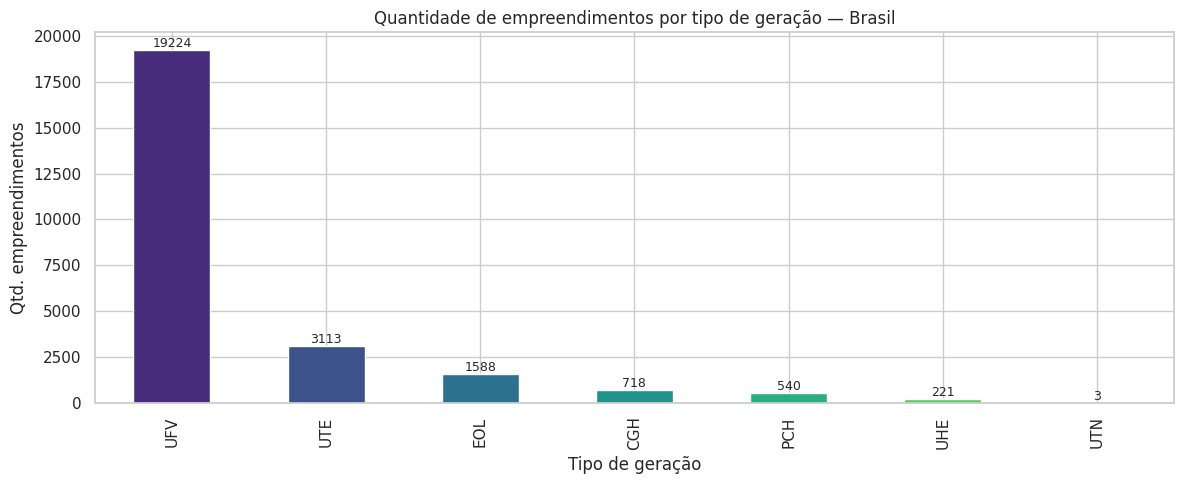

In [34]:
# ── Distribuição por tipo de geração ─────────────────────────────────────────
tipo_count = df_siga['SigTipoGeracao'].value_counts()
ax = tipo_count.plot(kind='bar',
                     color=sns.color_palette('viridis', len(tipo_count)))
ax.set_title('Quantidade de empreendimentos por tipo de geração — Brasil')
ax.set_xlabel('Tipo de geração')
ax.set_ylabel('Qtd. empreendimentos')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

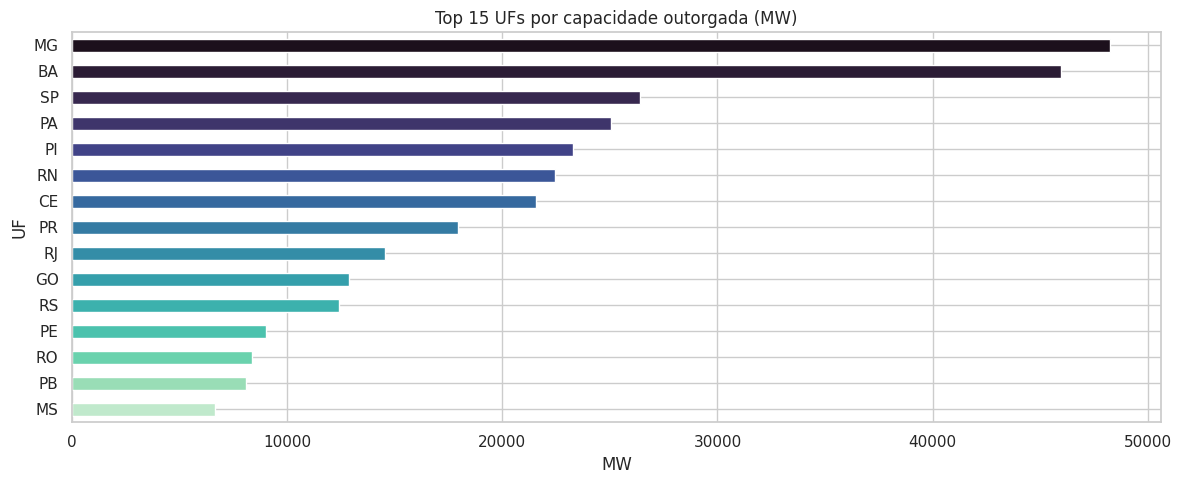

In [35]:
# ── Top 15 UFs por capacidade outorgada (MW) ─────────────────────────────────
cap_uf = (df_siga.groupby('SigUFPrincipal')['MdaPotenciaOutorgadaKw']
          .sum().div(1000).sort_values(ascending=False).head(15))
ax = cap_uf.plot(kind='barh',
                 color=sns.color_palette('mako', len(cap_uf)))
ax.invert_yaxis()
ax.set_title('Top 15 UFs por capacidade outorgada (MW)')
ax.set_xlabel('MW')
ax.set_ylabel('UF')
plt.tight_layout()
plt.show()

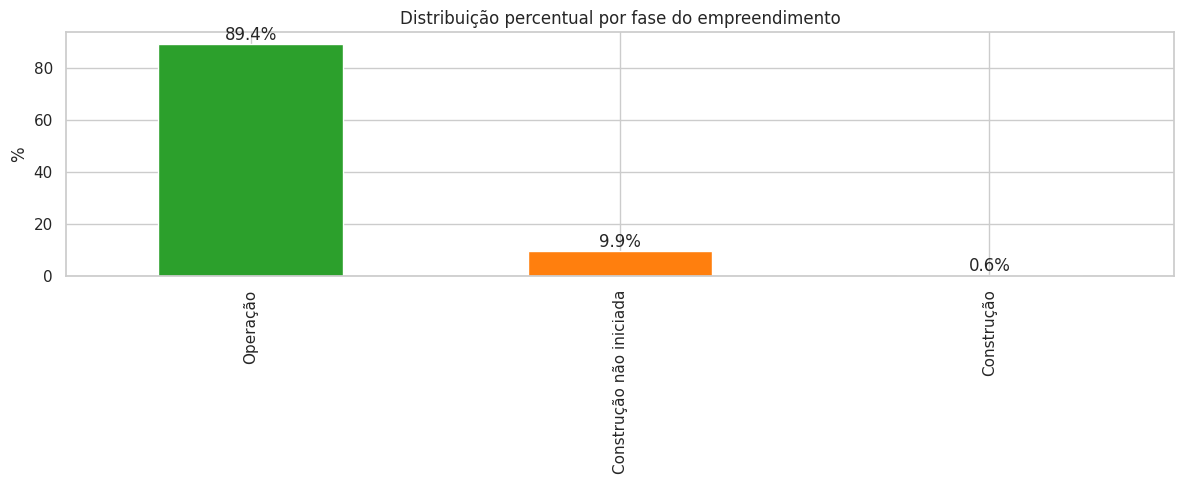

In [36]:
# ── Distribuição percentual por fase ──────────────────────────────────────────
fase = df_siga['DscFaseUsina'].value_counts(normalize=True).mul(100).round(2)
ax = fase.plot(kind='bar',
               color=['#2ca02c', '#ff7f0e', '#d62728', '#7f7f7f'])
ax.set_title('Distribuição percentual por fase do empreendimento')
ax.set_ylabel('%')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [37]:
# ── Mapa interativo: empreendimentos em operação ──────────────────────────────
df_mapa = emp.dropna(subset=['lat', 'lon'])
df_mapa = df_mapa[df_mapa['DscFaseUsina'] == 'Operação'].sample(
    min(3000, len(df_mapa)), random_state=42
)
fig = px.scatter_mapbox(
    df_mapa, lat='lat', lon='lon',
    color='SigTipoGeracao',
    size='MdaPotenciaOutorgadaKw',
    hover_name='NomEmpreendimento',
    hover_data={'SigUFPrincipal': True,
                'MdaPotenciaOutorgadaKw': ':.0f',
                'dc_proximos': True},
    zoom=3, height=600,
    title='Empreendimentos em Operação (amostra) — cor: tipo de geração'
)
fig.update_layout(mapbox_style='open-street-map',
                  margin=dict(r=0, t=30, l=0, b=0))
fig.show()

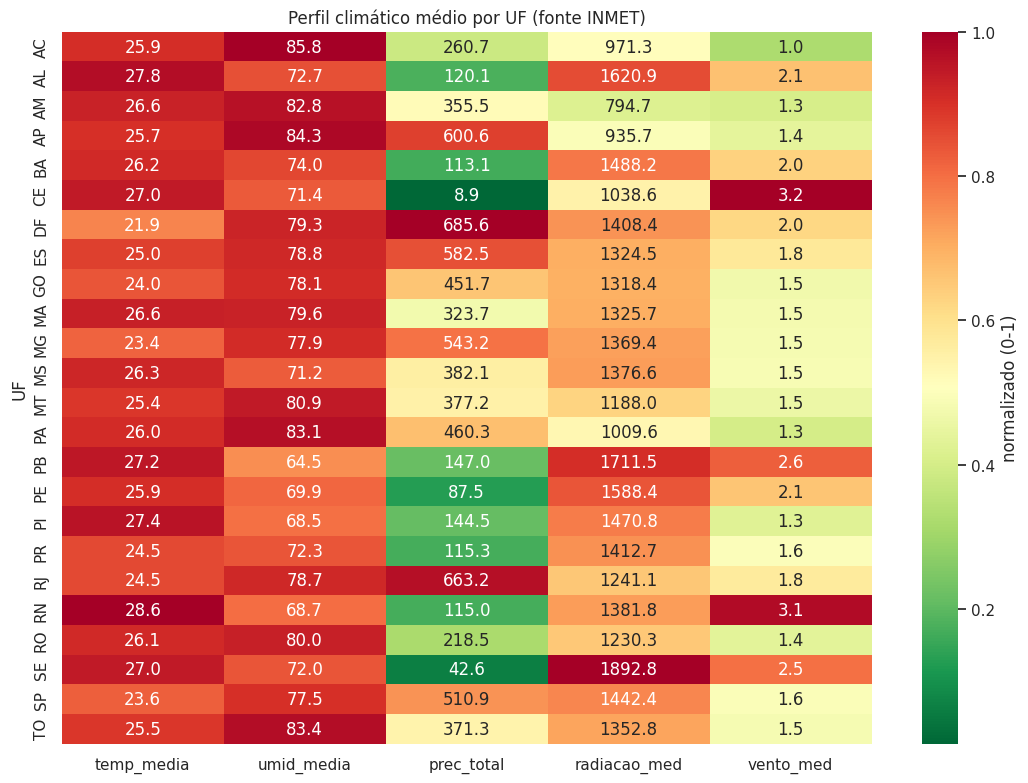

In [38]:
# ── Heatmap: perfil climático por UF ─────────────────────────────────────────
UF_LIST = [
    'AC','AL','AM','AP','BA','CE','DF','ES','GO','MA','MG','MS','MT',
    'PA','PB','PE','PI','PR','RJ','RN','RO','RR','RS','SC','SE','SP','TO'
]
clima_uf = silver_inmet.groupby('UF')[
    ['temp_media', 'umid_media', 'prec_total', 'radiacao_med', 'vento_med']
].mean()
clima_uf = clima_uf.reindex(UF_LIST).dropna()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(clima_uf.div(clima_uf.max()),
            annot=clima_uf.round(1), fmt='.1f',
            cmap='RdYlGn_r',
            cbar_kws={'label': 'normalizado (0-1)'},
            ax=ax)
ax.set_title('Perfil climático médio por UF (fonte INMET)')
plt.tight_layout()
plt.show()

In [39]:
# ── Cobertura ANATEL × Capacidade ANEEL por UF ───────────────────────────────
fig_uf = (
    df_siga.groupby('SigUFPrincipal')['MdaPotenciaOutorgadaKw']
    .sum().div(1000)
    .reset_index(name='cap_MW')
    .merge(silver_anatel[['UF', 'anatel_total']],
           left_on='SigUFPrincipal', right_on='UF')
)
fig = px.scatter(
    fig_uf, x='anatel_total', y='cap_MW', text='UF',
    size='cap_MW', color='cap_MW', color_continuous_scale='viridis',
    title='Cobertura telecom (ANATEL) × Capacidade energética (ANEEL) por UF',
    labels={
        'anatel_total': 'Contratos ANATEL (proxy de fibra)',
        'cap_MW': 'Capacidade outorgada (MW)',
    }
)
fig.update_traces(textposition='top center')
fig.show()

## Insights da Análise Exploratória de Dados (EDA)

Com base na Análise Exploratória de Dados (EDA) realizada na seção 2.7, os seguintes insights foram observados:

*   **Resumo Estatístico:** As colunas de potência (`MdaPotenciaOutorgadaKw`, `MdaPotenciaFiscalizadaKw`, `MdaGarantiaFisicaKw`) apresentaram uma ampla variação, com valores mínimos e máximos significativos, indicando a diversidade dos empreendimentos. Foi notado um alto percentual de valores nulos em colunas como `DscSubBacia` (94.27%), `DatFimVigencia` (77.29%), `DatInicioVigencia` (77.25%) e `IdcGeracaoQualificada` (62.81%), o que pode impactar análises futuras que dependam dessas informações. A coluna `lon` também apresentou uma pequena porcentagem de nulos (1.39%).

*   **Distribuição por Tipo de Geração:** A maioria dos empreendimentos de geração são UFV (Unidades Fotovoltaicas Solares), seguidas por UTE (Termelétricas) e EOL (Eólicas), indicando uma forte tendência para fontes renováveis e térmicas no portfólio de energia.

*   **Capacidade Outorgada por UF:** Estados como Minas Gerais (MG), Bahia (BA), São Paulo (SP) e Pará (PA) lideram em capacidade outorgada de energia, sugerindo que essas regiões possuem infraestrutura energética mais desenvolvida.

*   **Fase dos Empreendimentos:** A grande maioria dos empreendimentos (cerca de 89.43%) está em fase de 'Operação', enquanto uma parcela significativa (9.95%) está em 'Construção não iniciada', e uma pequena parte (0.63%) em 'Construção'. Isso mostra que muitos projetos estão ativos, mas há um potencial considerável de expansão futura.

*   **Mapa Interativo de Empreendimentos:** O mapa de empreendimentos em operação revelou a distribuição geográfica das usinas, com destaque para a concentração de diferentes tipos de geração em regiões específicas do Brasil. Isso é crucial para entender a oferta de energia localizada.

*   **Perfil Climático por UF:** O heatmap do perfil climático por UF forneceu uma visão clara das condições ambientais médias em cada estado (temperatura, umidade, precipitação, radiação, vento). Essas informações são vitais para o planejamento da localização de um datacenter, considerando custos de refrigeração, riscos de enchentes e potencial para uso de energia solar/eólica.

*   **Cobertura ANATEL vs. Capacidade ANEEL por UF:** O gráfico de dispersão mostrou a relação entre a cobertura de telecomunicações (proxy de fibra) e a capacidade energética outorgada por UF. Isso ajuda a identificar estados que são bem servidos tanto em termos de energia quanto de conectividade, fatores críticos para a implantação de datacenters.

---

## ✅ Etapa 2 — Concluída

| Coleção Silver/Gold                  | Conteúdo                                   |
|--------------------------------------|--------------------------------------------|
| `silver_siga`                        | ANEEL limpo, tipado, coordenadas WGS-84    |
| `silver_inmet`                       | Estatísticas climáticas por estação        |
| `silver_anatel_uf`                   | Contratos ANATEL por UF                    |
| `silver_datacenters`                 | DCs com geocodificação por cidade          |
| `gold_empreendimentos_features`      | Feature store completa para ML (Etapa 3)   |

> **Próximo passo:** execute a Etapa 3 (`Etapa3_ML_Modelos.ipynb`) que carrega  
> `gold_empreendimentos_features` e treina os modelos de classificação e regressão.